In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import torch
import torchvision.transforms.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


In [7]:
image_path = "/kaggle/input/firstimage/1.jpeg"
img = Image.open(image_path).convert("RGB")

print("Original image size:", img.size)


Original image size: (256, 256)


In [9]:
#Resizing
img_resized = F.resize(img, size=[128, 128])


In [10]:
#grey scale
img_gray = F.rgb_to_grayscale(img_resized, num_output_channels=1)


In [11]:
#auto-constrast
img_autocontrast = F.autocontrast(img_gray)


In [12]:
#brightness
brightness_factor = 1.2
img_bright = F.adjust_brightness(img_autocontrast, brightness_factor)


In [13]:
#shape
img_tensor = F.to_tensor(img_bright)  # shape: (1, 128, 128)


In [14]:
#normalize
mean = img_tensor.mean()
std = img_tensor.std()

img_normalized = (img_tensor - mean) / (std + 1e-6)


In [15]:
img_final = img_normalized.unsqueeze(0)

print("Final tensor shape:", img_final.shape)


Final tensor shape: torch.Size([1, 1, 128, 128])


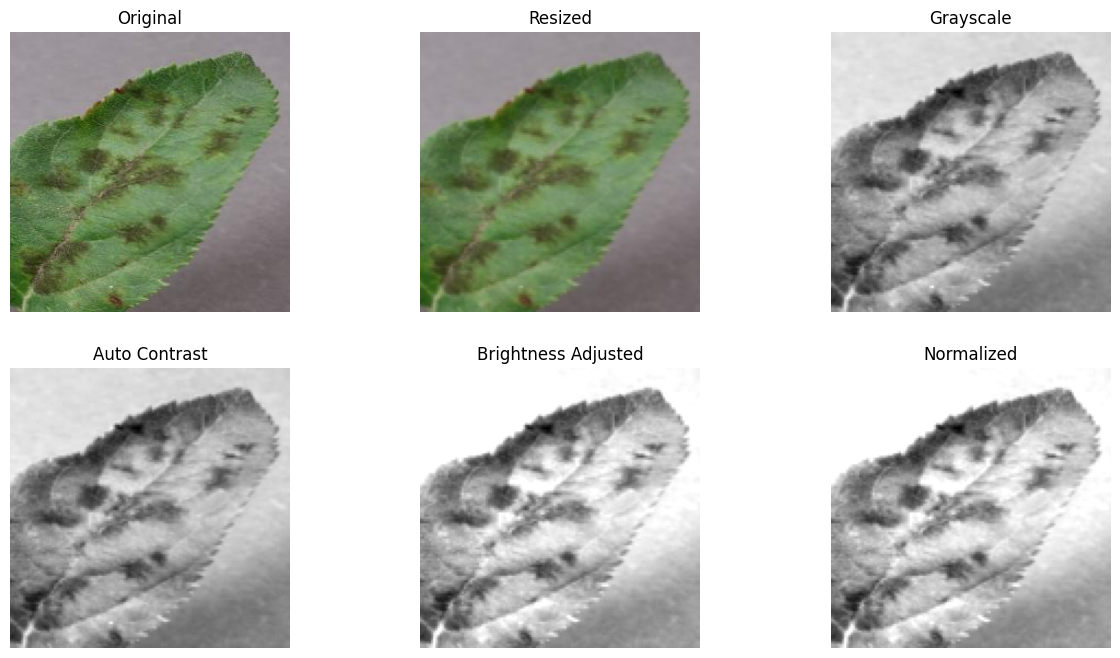

In [17]:
images = [
    img,
    img_resized,
    img_gray,
    img_autocontrast,
    img_bright,
    img_normalized.squeeze().numpy()
]

titles = [
    "Original",
    "Resized",
    "Grayscale",
    "Auto Contrast",
    "Brightness Adjusted",
    "Normalized"
]

plt.figure(figsize=(15, 8))
for i in range(len(images)):
    plt.subplot(2, 3, i + 1)

    if isinstance(images[i], Image.Image):
        plt.imshow(images[i], cmap="gray")
    else:
        plt.imshow(images[i], cmap="gray")

    plt.title(titles[i])
    plt.axis("off")

plt.show()
